# Fundación YPF - Data Science

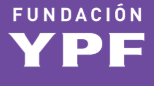

## Notebook 12: Transformación de datos y evaluación de distribuciones

###Parte 0 Repaso: carga, exploración, faltantes y outliers
###Parte 1 Evaluación de distribuciones
###Parte 2 Escalado: `StandardScaler`, `MinMaxScaler`, `RobustScaler`
###Parte 3 Normalizer(): qué hace realmente
###Parte 4 Transformar la forma: logaritmo y `PowerTransformer`
###Parte 5 Buenas prácticas: `fit` en train, `transform` en test
###Parte 6 Ejercicio para las salas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

<font size=5>  🔁 Parte 0 — Repaso 👩🏽‍💻</font>Antes de transformar, repasamos rápido lo que ya sabemos hacer: cargar, mirar los tipos, revisar faltantes y detectar outliers.Trabajamos con el dataset `StudentsPerformance`, que tiene variables numéricas continuas.

In [4]:
students = pd.read_csv('StudentsPerformance.csv')

In [2]:
# Si trabajás en Colab, subí el archivo con el panel de la izquierda.
try:
    students = pd.read_csv('/content/StudentsPerformance.csv')
except FileNotFoundError:
    students = pd.read_csv('StudentsPerformance.csv')

# La primera columna es un índice que se guardó por error al exportar el csv
if 'Unnamed: 0' in students.columns:
    students = students.drop(columns=['Unnamed: 0'])

students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,7.200,72,74
1,female,group C,some college,standard,completed,6.900,90,88
2,female,group B,master's degree,standard,none,9.000,95,93
3,male,group A,associate's degree,free/reduced,none,4.700,57,44
4,male,group C,some college,standard,none,7.600,78,75


In [5]:
students.shape

(1000, 9)

In [6]:
students.dtypes

,0
Unnamed: 0,int64
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,float64
reading score,int64
writing score,int64


**Repaso clase 6 — valores faltantes.** Siempre revisamos antes de transformar: un scaler no sabe qué hacer con un `NaN`.

In [7]:
students.isnull().sum()

,0
Unnamed: 0,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


**Repaso clase 6 — outliers con rango intercuartílico (RIC).**Recordemos el criterio: es outlier todo valor menor a `Q1 - 1.5*RIC` o mayor a `Q3 + 1.5*RIC`.

In [8]:
def contar_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    ric = q3 - q1
    limite_inf = q1 - 1.5 * ric
    limite_sup = q3 + 1.5 * ric
    return ((serie < limite_inf) | (serie > limite_sup)).sum()

for col in students.select_dtypes(include=np.number).columns:
    print(f'{col:20s} outliers: {contar_outliers(students[col])}')

Unnamed: 0           outliers: 0
math score           outliers: 8
reading score        outliers: 6
writing score        outliers: 5


**Repaso clase 7 — encoding.** Las categóricas las convertimos a numéricas antes de modelar.

In [11]:
students_enc = pd.get_dummies(students, columns=['gender', 'lunch'], drop_first=True)
students_enc.head(3)

,Unnamed: 0,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score,gender_male,lunch_standard
0,0,group B,bachelor's degree,none,7.200,72,74,False,True
1,1,group C,some college,completed,6.900,90,88,False,True
2,2,group B,master's degree,none,9.000,95,93,False,True


<font size=5>  📊 Parte 1 — Evaluación de distribuciones 👩🏽‍💻</font>Antes de decidir qué transformación aplicar, hay que **mirar la variable**. Empecemos por lo más básico: el `describe()`.

In [12]:
students.describe()

,Unnamed: 0,math score,reading score,writing score
count,"1,000.000","1,000.000","1,000.000","1,000.000"
mean,499.500,6.609,69.169,68.054
std,288.819,1.516,14.600,15.196
min,0.000,0.000,17.000,10.000
25%,249.750,5.700,59.000,57.750
50%,499.500,6.600,70.000,69.000
75%,749.250,7.700,79.000,79.000
max,999.000,10.000,100.000,100.000


### ⚠️ Primera observación importante
###Miremos con atención el `min` y el `max` de cada columna:
###- `math score` va de **0 a 10**
###- `reading score` y `writing score` van de **0 a 100**

###Las tres miden lo mismo (el rendimiento en una materia) pero **están en escalas distintas**. Para un algoritmo basado en distancias, `reading score` va a pesar diez veces más que `math score` solo por cómo está medida.Este es exactamente el problema que el escalado viene a resolver.

### 1.1 Métodos gráficos
###**Histograma:** nos muestra la forma general de la distribución.

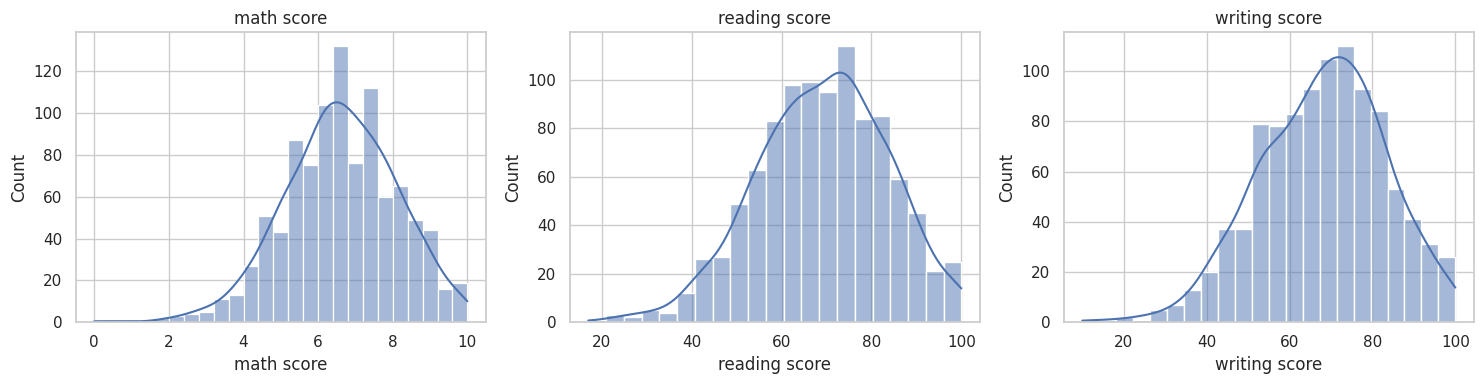

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    sns.histplot(students[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Boxplot:** mediana, dispersión y outliers de un vistazo.

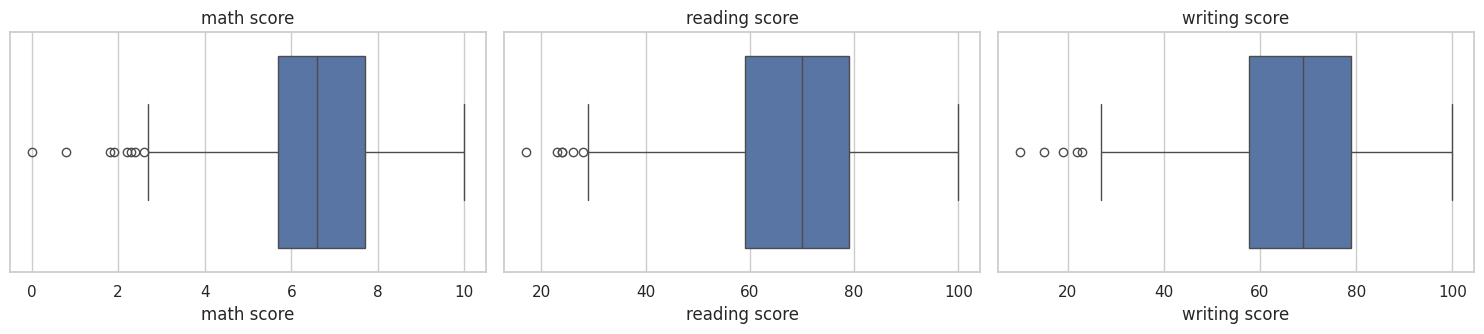

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    sns.boxplot(x=students[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

###**Q-Q plot:** compara los cuantiles observados contra los teóricos de una distribución normal.

###- Si los puntos siguen la línea diagonal → la variable es aproximadamente normal

###- Si se curvan en los extremos → hay colas pesadas o asimetría

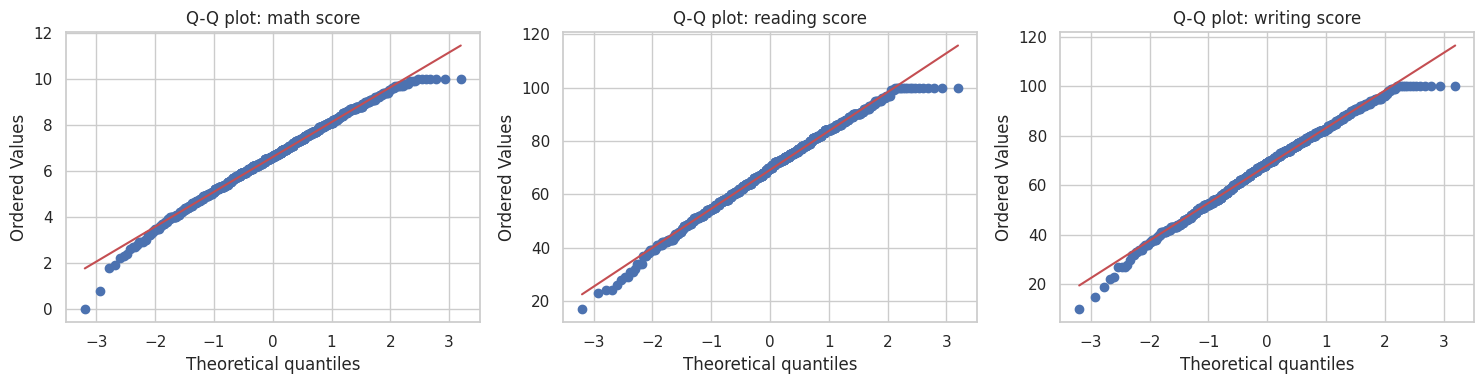

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    stats.probplot(students[col], dist="norm", plot=ax)
    ax.set_title(f'Q-Q plot: {col}')
plt.tight_layout()
plt.show()

### 1.2 Medidas numéricas

###**Asimetría (skewness):** cuánto se corre la distribución hacia un lado.

###≈ 0 → simétrica
###> 0 → cola hacia la derecha
###< 0 → cola hacia la izquierda

###Regla práctica: `|skew| < 0.5` es aceptable, `|skew| > 1` pide transformación.

####**Curtosis (kurtosis):** cuán pesadas son las colas respecto de una normal.

In [16]:
resumen = pd.DataFrame({
    'asimetria': students.select_dtypes(include=np.number).skew(),
    'curtosis': students.select_dtypes(include=np.number).kurt()
})
resumen

,asimetria,curtosis
Unnamed: 0,0.000,-1.200
math score,-0.279,0.275
reading score,-0.259,-0.068
writing score,-0.289,-0.033


### 1.3 Tests de normalidad`H0`: los datos provienen de una distribución normal.

### Si el **p-valor < 0.05**, rechazamos `H0`.

###⚠️ **Cuidado con el tamaño de la muestra.** Con muchos datos, cualquier desviación mínima da significativa y el test rechaza casi siempre. Con `n` grande, el histograma y el Q-Q plot deciden mejor que el p-valor.

In [17]:
for col in ['math score', 'reading score', 'writing score']:
    estadistico, p_valor = stats.shapiro(students[col])
    conclusion = 'NO normal' if p_valor < 0.05 else 'compatible con normal'
    print(f'{col:20s} p-valor = {p_valor:.4f}  ->  {conclusion}')

math score           p-valor = 0.0001  ->  NO normal
reading score        p-valor = 0.0001  ->  NO normal
writing score        p-valor = 0.0000  ->  NO normal


### ☝️ Atención al resultado

###El test rechaza la normalidad en las tres variables. Pero si volvemos a mirar la evidencia completa:

###- La asimetría de las tres está entre **-0.28 y -0.29**, muy por debajo del umbral de 0.5

###- Los Q-Q plots siguen la diagonal casi perfectamente
###- Tenemos **n = 1000**. Este es exactamente el caso del que hablábamos con muestras grandes, el test detecta desviaciones mínimas y rechaza igual.

###**El test no manda solo.** Acá los gráficos y la asimetría dicen que las variables son perfectamente usables.

###**Conclusión de la Parte 1:** las tres variables son razonablemente simétricas. No necesitan que les cambiemos la forma. Lo que sí necesitan es **quedar en la misma escala**.

<font size=5> ⚖️ Parte 2 — Escalado de variables 👩🏽‍💻

### Idea clave *Escalar y transformar la forma no son lo mismo*.

###Escalar cambia *dónde* está centrada la variable y *cuánto* mide su unidad. **La forma de la distribución queda igual.**

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

### 2.1 `StandardScaler()` — EstandarizaciónDeja la variable con **media 0** y **desvío estándar 1**.$$z = \frac{x - \mu}{\sigma}$$Es el mismo z-score que usamos en la clase 6 para detectar outliers.

In [19]:
scaler_std = StandardScaler()

# Creamos una columna nueva: NO pisamos la original, la vamos a necesitar para comparar
students['math_std'] = scaler_std.fit_transform(students[['math score']])

print('Original   -> media: %.3f  desvio: %.3f' % (students['math score'].mean(), students['math score'].std()))
print('Estandarizada -> media: %.3f  desvio: %.3f' % (students['math_std'].mean(), students['math_std'].std()))

Original   -> media: 6.609  desvio: 1.516
Estandarizada -> media: 0.000  desvio: 1.001


*(Si el desvío da 1.001 en vez de 1.000 exacto: es porque pandas divide por `n-1` y scikit-learn por `n`. Con 1000 filas la diferencia es despreciable.)*Los parámetros que aprendió el scaler quedan guardados en el objeto. Esto es importante: son los que vamos a reutilizar sobre datos nuevos.

In [20]:
print('Media aprendida (mean_):  ', scaler_std.mean_)
print('Escala aprendida (scale_):', scaler_std.scale_)

Media aprendida (mean_):   [6.6089]
Escala aprendida (scale_): [1.51554967]


### 2.2 `MinMaxScaler()` — Re-escaladoLleva todos los valores al rango **[0, 1]**.$$x' = \frac{x - min}{max - min}$$

In [21]:
scaler_mm = MinMaxScaler()
students['math_minmax'] = scaler_mm.fit_transform(students[['math score']])

print('Minimo: %.3f   Maximo: %.3f' % (students['math_minmax'].min(), students['math_minmax'].max()))

Minimo: 0.000   Maximo: 1.000


### 2.3 `RobustScaler()` — Escalado robustoUsa **mediana** y **rango intercuartílico** en vez de media y desvío. Es la opción cuando hay outliers que no queremos eliminar, porque la mediana y el RIC casi no se mueven ante valores extremos.$$x' = \frac{x - mediana}{RIC}$$

In [22]:
scaler_rb = RobustScaler()
students['math_robust'] = scaler_rb.fit_transform(students[['math score']])

students[['math score', 'math_std', 'math_minmax', 'math_robust']].describe()

,math score,math_std,math_minmax,math_robust
count,"1,000.000","1,000.000","1,000.000","1,000.000"
mean,6.609,0.000,0.661,0.004
std,1.516,1.001,0.152,0.758
min,0.000,-4.361,0.000,-3.300
25%,5.700,-0.600,0.570,-0.450
50%,6.600,-0.006,0.660,0.000
75%,7.700,0.720,0.770,0.550
max,10.000,2.238,1.000,1.700


### 2.4 Comparación visual: la forma no cambiaMiremos las cuatro versiones de la misma variable. Prestá atención al **eje x** de cada gráfico: es lo único que cambia.

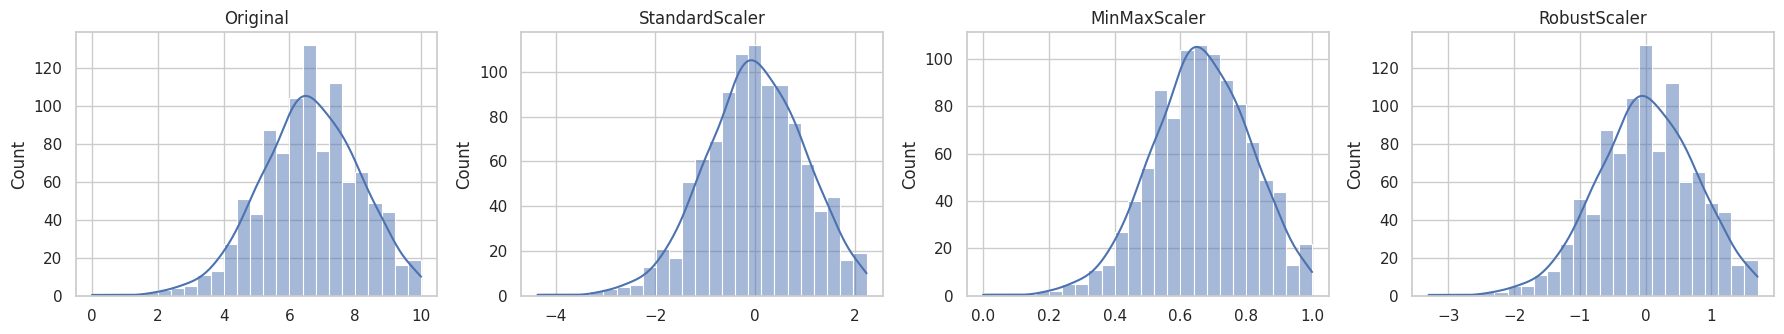

Asimetria de cada version:
math score    -0.279
math_std      -0.279
math_minmax   -0.279
math_robust   -0.279
dtype: float64


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
columnas = ['math score', 'math_std', 'math_minmax', 'math_robust']
titulos = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']

for ax, col, titulo in zip(axes, columnas, titulos):
    sns.histplot(students[col], kde=True, ax=ax, bins=25)
    ax.set_title(titulo)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('Asimetria de cada version:')
print(students[columnas].skew())

☝️ **La asimetría es idéntica en las cuatro.** Escalar no arregla una distribución sesgada: solo la mueve de lugar.

### 2.5 ¿Y el efecto de los outliers?
###Veamos qué pasa con cada scaler cuando metemos un valor extremo. Simulamos que se cargó mal una nota: un 100 donde la escala llega hasta 10.

In [24]:
math_con_outlier = pd.DataFrame({
    'math': list(students['math score']) + [100.0]   # <- un valor mal cargado
})

comparacion = pd.DataFrame({
    'StandardScaler': StandardScaler().fit_transform(math_con_outlier)[:, 0],
    'MinMaxScaler':   MinMaxScaler().fit_transform(math_con_outlier)[:, 0],
    'RobustScaler':   RobustScaler().fit_transform(math_con_outlier)[:, 0],
})

# Miramos solo los datos reales, sin el outlier, para ver cuanto los comprimio
print('Rango que ocupan los datos reales despues de escalar (sin contar el outlier):')
print((comparacion[:-1].max() - comparacion[:-1].min()).round(3))

Rango que ocupan los datos reales despues de escalar (sin contar el outlier):
StandardScaler   3.015
MinMaxScaler     0.100
RobustScaler     5.000
dtype: float64


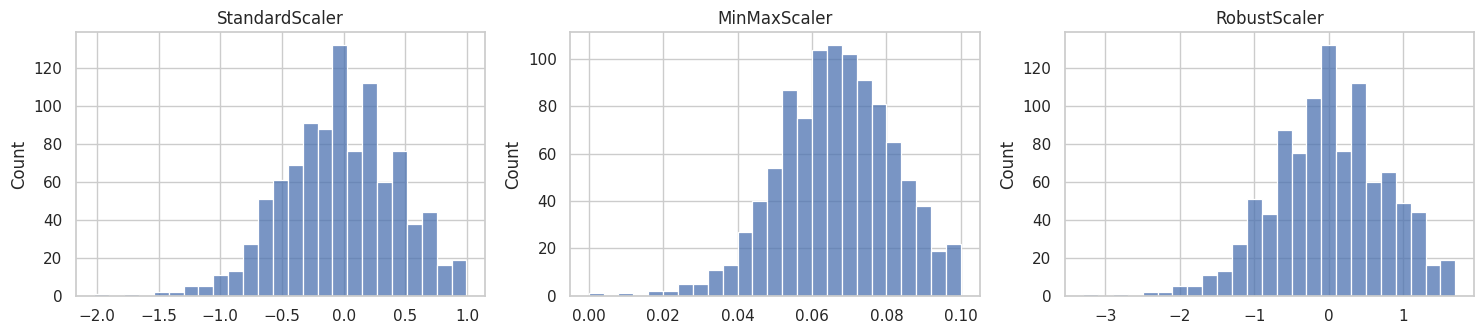

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, comparacion.columns):
    sns.histplot(comparacion[col][:-1], ax=ax, bins=25)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### ¿Cómo se lee ese número?

###Es el espacio que ocupan los **datos reales** después de escalar. Cuanto más grande, menos comprimidos quedaron:

- `MinMaxScaler` → **0.10**: los mil datos reales quedaron aplastados en el 10% del rango. El outlier se llevó el resto
- `StandardScaler` → **3.02**: bastante mejor, aunque la media y el desvío igual se corrieron
- `RobustScaler` → **5.00**: prácticamente no se inmutó, porque la mediana y el RIC no se mueven por un valor extremo

###Este es el argumento para usar `RobustScaler` cuando el boxplot muestra outliers que no queremos eliminar.

<font size=5> Parte 3 `Normalizer()`: ¿qué hace realmente?

###Acá hay que tener mucho cuidado, porque el nombre confunde.

###`Normalizer()` NO vuelve normal una distribución y NO lleva los valores a [0, 1].

###Opera **por fila, no por columna**: escala cada observación para que su vector tenga **norma 1**.

###Veamos qué pasa si lo aplicamos a una sola columna, como se hace habitualmente por error:

In [26]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
resultado = normalizer.fit_transform(students[['writing score']])

print('Valores unicos del resultado:', np.unique(resultado))
print('Cantidad de filas:', len(resultado))

Valores unicos del resultado: [1.]
Cantidad de filas: 1000


### ☝️ Todas las filas valen 1.0 y tiene sentido: si una fila tiene un solo número `[x]`, su norma es `|x|`, y al dividirlo por su propia norma queda `1`.

###Perdimos toda la información de la variable. Aplicar `Normalizer()` a una columna sola no es una transformación: es borrar los datos.

### ¿Entonces para qué sirve? Para cuando importa la **dirección** del vector de cada observación y no su magnitud: TF-IDF y texto, similitud coseno, sistemas de recomendación. Se aplica sobre **varias columnas a la vez**.

In [27]:
ejemplo = students[['reading score', 'writing score']].head(5)
normalizado = Normalizer().fit_transform(ejemplo)

print('Filas originales:')
print(ejemplo.values)
print('\nFilas normalizadas (cada una con norma 1):')
print(normalizado.round(3))
print('\nNorma de cada fila:', np.linalg.norm(normalizado, axis=1).round(3))

Filas originales:
[[72 74]
 [90 88]
 [95 93]
 [57 44]
 [78 75]]

Filas normalizadas (cada una con norma 1):
[[0.697 0.717]
 [0.715 0.699]
 [0.715 0.7  ]
 [0.792 0.611]
 [0.721 0.693]]

Norma de cada fila: [1. 1. 1. 1. 1.]


<font size=5> 🔧 Parte 4 Transformar la forma 👩🏽‍💻

###Hasta ahora trabajamos con variables ya simétricas. Cambiamos a un dataset donde hay asimetría real: `life_expectancy_data`.

In [28]:
vida = pd.read_csv('life_expectancy_data.csv')

In [24]:
try:
    vida = pd.read_csv('/content/life_expectancy_data.csv')
except FileNotFoundError:
    vida = pd.read_csv('life_expectancy_data.csv')

vida.columns = vida.columns.str.strip()   # los nombres vienen con espacios de mas
vida.head(3)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.000,263.000,62,0.010,71.280,65.000,1154,...,6.000,8.160,65.000,0.100,584.259,"33,736,494.000",17.200,17.300,0.479,10.100
1,Afghanistan,2014,Developing,59.900,271.000,64,0.010,73.524,62.000,492,...,58.000,8.180,62.000,0.100,612.697,"327,582.000",17.500,17.500,0.476,10.000
2,Afghanistan,2013,Developing,59.900,268.000,66,0.010,73.219,64.000,430,...,62.000,8.130,64.000,0.100,631.745,"31,731,688.000",17.700,17.700,0.470,9.900


In [29]:
vida

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.000,263.000,62,0.010,71.280,65.000,1154,...,6.000,8.160,65.000,0.100,584.259,"33,736,494.000",17.200,17.300,0.479,10.100
1,Afghanistan,2014,Developing,59.900,271.000,64,0.010,73.524,62.000,492,...,58.000,8.180,62.000,0.100,612.697,"327,582.000",17.500,17.500,0.476,10.000
2,Afghanistan,2013,Developing,59.900,268.000,66,0.010,73.219,64.000,430,...,62.000,8.130,64.000,0.100,631.745,"31,731,688.000",17.700,17.700,0.470,9.900
3,Afghanistan,2012,Developing,59.500,272.000,69,0.010,78.184,67.000,2787,...,67.000,8.520,67.000,0.100,669.959,"3,696,958.000",17.900,18.000,0.463,9.800
4,Afghanistan,2011,Developing,59.200,275.000,71,0.010,7.097,68.000,3013,...,68.000,7.870,68.000,0.100,63.537,"2,978,599.000",18.200,18.200,0.454,9.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.300,723.000,27,4.360,0.000,68.000,31,...,67.000,7.130,65.000,33.600,454.367,"12,777,511.000",9.400,9.400,0.407,9.200
2934,Zimbabwe,2003,Developing,44.500,715.000,26,4.060,0.000,7.000,998,...,7.000,6.520,68.000,36.700,453.351,"12,633,897.000",9.800,9.900,0.418,9.500
2935,Zimbabwe,2002,Developing,44.800,73.000,25,4.430,0.000,73.000,304,...,73.000,6.530,71.000,39.800,57.348,"125,525.000",1.200,1.300,0.427,10.000
2936,Zimbabwe,2001,Developing,45.300,686.000,25,1.720,0.000,76.000,529,...,76.000,6.160,75.000,42.100,548.587,"12,366,165.000",1.600,1.700,0.427,9.800


### 4.1 DiagnósticoOrdenamos las variables numéricas por asimetría para ver cuáles necesitan atención.

In [30]:
asimetrias = vida.select_dtypes(include=np.number).skew().sort_values(ascending=False)
asimetrias.head(8)

,0
Population,15.916
infant deaths,9.787
under-five deaths,9.495
Measles,9.441
HIV/AIDS,5.396
percentage expenditure,4.652
GDP,3.207
thinness 5-9 years,1.777


`GDP` (PBI per cápita) tiene una asimetría muy alta. Miremos su distribución.

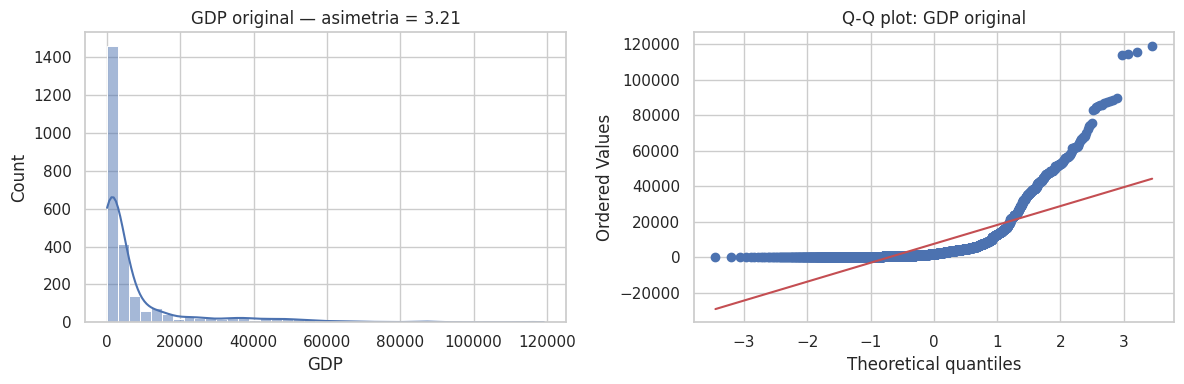

In [31]:
gdp = vida['GDP'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(gdp, kde=True, ax=axes[0], bins=40)
axes[0].set_title(f'GDP original — asimetria = {gdp.skew():.2f}')
stats.probplot(gdp, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot: GDP original')
plt.tight_layout()
plt.show()

Cola larguísima a la derecha y un Q-Q plot completamente curvado. Este es el caso donde escalar **no alcanza**.
### 4.2 Transformación logarítmica`np.log1p(x)` calcula `log(1 + x)`, así que tolera los ceros.

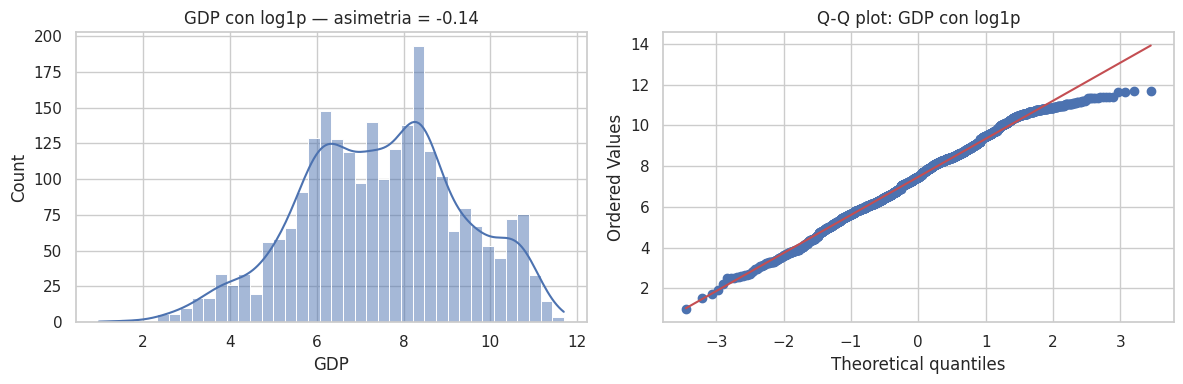

In [32]:
gdp_log = np.log1p(gdp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(gdp_log, kde=True, ax=axes[0], bins=40)
axes[0].set_title(f'GDP con log1p — asimetria = {gdp_log.skew():.2f}')
stats.probplot(gdp_log, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot: GDP con log1p')
plt.tight_layout()
plt.show()

De `3.21` a un valor mucho más cercano a 0, y el Q-Q plot se acomodó sobre la diagonal.

### 4.3 `PowerTransformer()` — Yeo-Johnson

###En vez de elegir la transformación a ojo, `PowerTransformer` **busca el exponente λ que más acerca la variable a una normal**.- `method='box-cox'` → solo valores estrictamente positivos- `method='yeo-johnson'` → acepta ceros y negativos (es el valor por defecto)

In [33]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
gdp_pt = pt.fit_transform(gdp.values.reshape(-1, 1))[:, 0]

print('Lambda encontrado:', pt.lambdas_.round(4))
print('Asimetria original:      %.3f' % gdp.skew())
print('Asimetria con log1p:     %.3f' % gdp_log.skew())
print('Asimetria con Yeo-Johnson: %.3f' % pd.Series(gdp_pt).skew())

Lambda encontrado: [0.0297]
Asimetria original:      3.207
Asimetria con log1p:     -0.141
Asimetria con Yeo-Johnson: -0.008


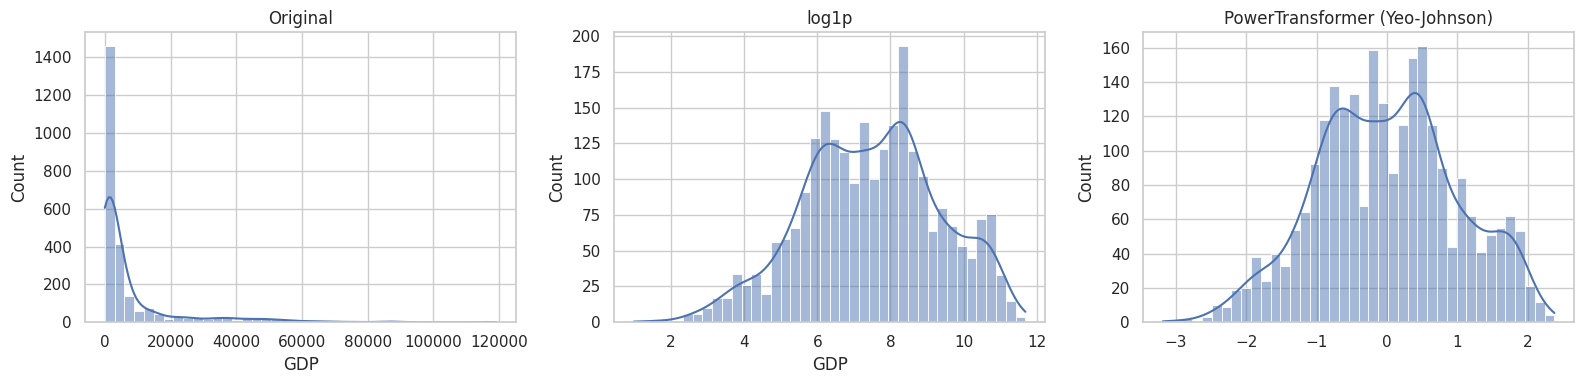

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(gdp, kde=True, ax=axes[0], bins=40)
axes[0].set_title('Original')
sns.histplot(gdp_log, kde=True, ax=axes[1], bins=40)
axes[1].set_title('log1p')
sns.histplot(gdp_pt, kde=True, ax=axes[2], bins=40)
axes[2].set_title('PowerTransformer (Yeo-Johnson)')
plt.tight_layout()
plt.show()

⚠️ **Ojo con la interpretación.** Si transformamos una variable, el modelo predice en la escala transformada. Para volver a la escala original usamos `np.expm1()` en el caso del logaritmo, o `pt.inverse_transform()` en el caso de `PowerTransformer`.

In [35]:
# Volvemos a la escala original
gdp_recuperado = pt.inverse_transform(gdp_pt.reshape(-1, 1))[:, 0]
print('Primeros valores originales: ', gdp.values[:4].round(2))
print('Primeros valores recuperados:', gdp_recuperado[:4].round(2))

Primeros valores originales:  [584.26 612.7  631.74 669.96]
Primeros valores recuperados: [584.26 612.7  631.74 669.96]


<font size=5>  ✅ Parte 5 — Buenas prácticas: `fit` en train, `transform` en test 👩🏽‍💻</font>

Este es **el error más común** al escalar, y el más caro. El scaler aprende parámetros de los datos (media, desvío, mínimo, máximo). Si los aprende del dataset completo, información del test se filtra al entrenamiento. Eso se llama **data leakage** y hace que las métricas parezcan mejores de lo que son.

In [37]:
from sklearn.model_selection import train_test_split

X = students[['math score', 'reading score', 'writing score']]
y = students['gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (800, 3)   Test: (200, 3)


In [38]:
# ✅ CORRECTO
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)   # fit_transform SOLO en train
X_test_esc  = scaler.transform(X_test)        # solo transform en test

print('Parametros aprendidos SOLO de train:')
print('  media: ', scaler.mean_.round(3))
print('  escala:', scaler.scale_.round(3))

Parametros aprendidos SOLO de train:
  media:  [ 6.65  69.555 68.456]
  escala: [ 1.501 14.452 15.076]


Comparemos con la forma incorrecta, para ver que los parámetros efectivamente cambian:

In [39]:
# ❌ INCORRECTO: ajustar sobre todo el dataset antes de separar
scaler_mal = StandardScaler()
scaler_mal.fit(X)

comparacion_fit = pd.DataFrame({
    'correcto (solo train)': scaler.mean_,
    'incorrecto (todo el dataset)': scaler_mal.mean_
}, index=X.columns)

comparacion_fit

,correcto (solo train),incorrecto (todo el dataset)
math score,6.650,6.609
reading score,69.555,69.169
writing score,68.456,68.054


La diferencia acá es chica porque el dataset está balanceado, pero **el principio no se negocia**: en un caso real con outliers concentrados en el test, la diferencia puede ser enorme.

📌 **Regla:** `fit_transform` una sola vez, sobre train. Sobre todo lo demás, `transform`. Esto aplica igual a `PowerTransformer`, a los encoders de la Notebook 11 y a los imputadores de la Notebook 9.

### ¿Y qué variables escalamos?

In [41]:
# Las dummies ya estan en escala 0/1: no hace falta escalarlas
numericas = ['math score', 'reading score', 'writing score']
dummies = [c for c in students_enc.columns if students_enc[c].dtype == bool]

print('Escalamos:   ', numericas)
print('NO escalamos:', dummies)

Escalamos:    ['math score', 'reading score', 'writing score']
NO escalamos: ['gender_male', 'lunch_standard']


## 🎯 Parte 6. Ejercicio para las salas 👩🏽‍💻

**Tiempo: 40 minutos.**

Trabajen en los grupos establecidos. Después ponemos en común.

Vamos a usar el dataset `life_expectancy_data`, que ya cargamos como `vida`.

### Consigna

**1. Diagnóstico (10 min)**

Elegí **tres** variables numéricas del dataset. Para cada una:

- Graficá el histograma y el Q-Q plot.
- Calculá la asimetría.
- Contá cuántos outliers tiene según el criterio del RIC.
- Anotá en una celda markdown qué encontraste.

**2. Decisión (5 min)**

Para cada variable, decidí y **justificá por escrito** qué le vas a aplicar:

- ¿Necesita que le cambiemos la forma, o solo la escala?
- Si necesita escalado, ¿cuál de los tres scalers conviene y por qué?

**3. Aplicación (15 min)**

- Separá el dataset en train y test.
- Aplicá las transformaciones que decidiste, respetando `fit` en train y `transform` en test.
- Guardá los resultados en columnas nuevas, sin pisar las originales.

**4. Verificación (10 min)**

- Volvé a graficar el histograma y el Q-Q plot de las variables transformadas.
- Volvé a calcular la asimetría.
- ¿Mejoró? Si no mejoró, ¿por qué te parece que pasó?

### 💡 Pistas

- `vida.columns = vida.columns.str.strip()` ya está hecho, así que los nombres están limpios.
- Varias columnas tienen faltantes. Revisá con `.isnull().sum()` antes de escalar.
- `Population` tiene una asimetría de casi 16. Es un buen caso para probar más de una transformación y comparar.
- Si una variable tiene ceros, `np.log()` va a fallar. Usá `np.log1p()`.

### 🚫 Errores para evitar

- Pisar la columna original al escalar, porque después no podés comparar.
- Hacer `fit_transform` sobre el dataset completo.
- Aplicar `Normalizer()` a una columna sola.
- Escalar sin haber mirado la distribución primero.

In [ ]:
# Escribí tu solución acá

In [ ]:
# students.to_csv('students_transformado.csv', index=False)